# Searchlight Partial Variance: VA vs CLIP-ViT

At each searchlight sphere, compute unique_VA and unique_CLIP from a two-model variance partition.
The output is a whole-brain map showing where unique_VA > unique_CLIP (and vice versa).

In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import pickle
from scipy.stats import spearmanr, ttest_1samp, zscore, rankdata, pearsonr
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LinearRegression
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [2]:
def upper_tri(RDM):
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

## 1. Load data

In [3]:
# Paths — Windows format
tmp_image_path = r'..\IAPS_fMRI_RSA\fMRI_singletrial_betas\nifti\Nt1.img'
tmp_img = nib.load(tmp_image_path)

# Load mask and searchlight centers
mask = np.load('.\\mask.npy')
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)
print(f'Mask shape: {mask.shape}')
print(f'Number of searchlight centers: {len(centers)}')

# Load subject data
allsub_avg = np.load('allsub_avg.npy', allow_pickle=True)
print(f'Subject data shape: {allsub_avg.shape}')

Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 9285.64it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Number of searchlight centers: 56949
Subject data shape: (20, 60, 153594)


## 2. Load model RDMs

In [4]:
# Load pre-computed model RDMs
rdm_beh = pd.read_csv(r'..\IAPS_Searchlight\RDM\rdm_behavioral.csv', index_col=0)
rdm_beh = np.array(rdm_beh)
va_rdm = (rdm_beh - np.min(rdm_beh)) / (np.max(rdm_beh) - np.min(rdm_beh))

rdm_clipvit = pd.read_csv(r'..\IAPS_Searchlight\RDM\rdm_clipvit.csv')
clip_rdm = np.array(rdm_clipvit)

# Vectorize model RDMs (done once, used at every searchlight sphere)
va_vec = upper_tri(va_rdm)
clip_vec = upper_tri(clip_rdm)

print(f'VA RDM shape: {va_rdm.shape}')
print(f'CLIP RDM shape: {clip_rdm.shape}')
print(f'Model vector length: {len(va_vec)}')

# Check inter-model correlation
r, _ = spearmanr(va_vec, clip_vec)
print(f'VA vs CLIP Spearman r = {r:.3f}')

VA RDM shape: (60, 60)
CLIP RDM shape: (60, 60)
Model vector length: 1770
VA vs CLIP Spearman r = 0.290


## 3. Define variance partitioning for a single searchlight sphere

In [5]:
def r2_ols(X, y):
    """Compute R² from OLS regression on z-scored inputs."""
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    Xz = np.nan_to_num(zscore(X, axis=0, ddof=1))
    yz = zscore(y, ddof=1)
    model = LinearRegression().fit(Xz, yz)
    return model.score(Xz, yz)


def variance_partition_2model(neural_vec, va_vec, clip_vec):
    """
    Two-model variance partitioning for one searchlight sphere.
    
    Returns: unique_VA, unique_CLIP, shared_VA_CLIP, R2_full
    """
    r2_va   = r2_ols(va_vec, neural_vec)
    r2_clip = r2_ols(clip_vec, neural_vec)
    r2_both = r2_ols(np.column_stack([va_vec, clip_vec]), neural_vec)
    
    unique_va   = r2_both - r2_clip
    unique_clip = r2_both - r2_va
    shared      = r2_va + r2_clip - r2_both
    
    return unique_va, unique_clip, shared, r2_both

## 4. Run searchlight variance partitioning

For each subject, at each searchlight sphere:
1. Compute the neural RDM from the sphere's voxels
2. Vectorize the upper triangle
3. Run two-model variance partition against VA and CLIP model RDMs
4. Store unique_VA, unique_CLIP, shared, R2_full per sphere

In [6]:
def process_subject(subj_idx, allsub_avg, centers, neighbors, va_vec, clip_vec, mask):
    """
    Process one subject: compute searchlight RDMs and variance partition at each sphere.
    
    Returns: (unique_va_map, unique_clip_map, shared_map, r2_full_map)
             each of shape (n_voxels,)
    """
    subj_data = np.nan_to_num(allsub_avg[subj_idx])
    image_value = np.arange(subj_data.shape[0])
    
    # Get searchlight RDMs for this subject
    SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
    voxel_indices = SL_RDM.rdm_descriptors['voxel_index']
    n_spheres = len(voxel_indices)
    
    unique_va_scores   = np.zeros(n_spheres)
    unique_clip_scores = np.zeros(n_spheres)
    shared_scores      = np.zeros(n_spheres)
    r2_full_scores     = np.zeros(n_spheres)
    
    for idx, rdm in enumerate(SL_RDM):
        neural_vec = np.nan_to_num(np.squeeze(rdm.dissimilarities))
        
        if np.std(neural_vec) < 1e-10:
            # Constant RDM — skip
            continue
        
        u_va, u_clip, shared, r2_full = variance_partition_2model(neural_vec, va_vec, clip_vec)
        unique_va_scores[idx]   = u_va
        unique_clip_scores[idx] = u_clip
        shared_scores[idx]      = shared
        r2_full_scores[idx]     = r2_full
    
    return voxel_indices, unique_va_scores, unique_clip_scores, shared_scores, r2_full_scores


# Run across all subjects
n_subjects = allsub_avg.shape[0]
n_voxels_total = len(centers)
x, y, z = mask.shape

# Storage: (n_subjects, n_searchlight_centers)
all_unique_va   = np.zeros((n_subjects, n_voxels_total))
all_unique_clip = np.zeros((n_subjects, n_voxels_total))
all_shared      = np.zeros((n_subjects, n_voxels_total))
all_r2_full     = np.zeros((n_subjects, n_voxels_total))

for subj in tqdm(range(n_subjects), desc='Subjects'):
    voxel_indices, u_va, u_clip, shared, r2_full = process_subject(
        subj, allsub_avg, centers, neighbors, va_vec, clip_vec, mask
    )
    all_unique_va[subj]   = u_va
    all_unique_clip[subj] = u_clip
    all_shared[subj]      = shared
    all_r2_full[subj]     = r2_full

print(f'Done. Shape: {all_unique_va.shape}')

# Save intermediate results
np.save('./outputs/searchlight_unique_va.npy', all_unique_va)
np.save('./outputs/searchlight_unique_clip.npy', all_unique_clip)
np.save('./outputs/searchlight_shared.npy', all_shared)
np.save('./outputs/searchlight_r2_full.npy', all_r2_full)

Subjects: 100%|██████████| 20/20 [56:47<00:00, 170.40s/it]


Done. Shape: (20, 56949)


## 5. Group statistics: t-test at each voxel

For each searchlight center, test whether unique_VA > 0, unique_CLIP > 0, and unique_VA > unique_CLIP across subjects.

In [7]:
# Load if needed
# all_unique_va   = np.load('./outputs/searchlight_unique_va.npy')
# all_unique_clip = np.load('./outputs/searchlight_unique_clip.npy')
# all_shared      = np.load('./outputs/searchlight_shared.npy')

# Get voxel indices from the last subject's SL_RDM (all subjects use the same centers)
subj_data = np.nan_to_num(allsub_avg[0])
image_value = np.arange(subj_data.shape[0])
SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
voxel_indices = np.array(SL_RDM.rdm_descriptors['voxel_index'])

Calculating RDMs...: 100%|██████████| 100/100 [00:47<00:00,  2.09it/s]


In [23]:
def compute_tmap(data, voxel_indices, mask_shape, tmp_img, 
                 fdr_alpha=0.001, cluster_threshold=50, label=''):
    """
    Compute group-level t-map from per-subject searchlight scores.
    
    data: (n_subjects, n_centers) array of per-subject scores
    Returns: t_stat_img_cluster (thresholded NIfTI image)
    """
    # Fisher z-transform
    epsilon = 1e-10
    data_clipped = np.clip(data, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(data_clipped)
    
    # One-sample t-test at each searchlight center
    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0)
    
    # FDR correction
    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig_voxels = np.where(p_fdr < fdr_alpha)[0]
    
    print(f'{label}: {len(sig_voxels)} significant voxels (FDR q < {fdr_alpha})')
    
    # Map to 3D volume
    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)
    t_map_3d[t_map_3d < 0] = np.nan  # keep only positive effects
    
    t_img = new_img_like(tmp_img, t_map_3d)
    t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
    
    return t_img_cluster, t_stats, p_fdr


# T-maps for unique_VA > 0 and unique_CLIP > 0
tmap_unique_va, t_va, p_va = compute_tmap(
    all_unique_va, voxel_indices, mask.shape, tmp_img, label='Unique VA')

tmap_unique_clip, t_clip, p_clip = compute_tmap(
    all_unique_clip, voxel_indices, mask.shape, tmp_img, label='Unique CLIP')

tmap_shared, t_shared, p_shared = compute_tmap(
    all_shared, voxel_indices, mask.shape, tmp_img, label='Shared VA-CLIP')

Unique VA: 3989 significant voxels (FDR q < 0.001)
Unique CLIP: 15843 significant voxels (FDR q < 0.001)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_30808\481822077.py:31: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_30808\481822077.py:31: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)


Shared VA-CLIP: 1 significant voxels (FDR q < 0.001)


In [11]:
# T-map for the CONTRAST: unique_VA > unique_CLIP (paired difference)
diff = all_unique_va - all_unique_clip  # (n_subjects, n_centers)

# t-test on the difference (two-sided: is unique_VA != unique_CLIP?)
t_diff, p_diff = ttest_1samp(diff, 0, axis=0)
rejected_diff, p_diff_fdr = fdrcorrection(p_diff, alpha=0.05)

# Map: positive t = VA > CLIP, negative t = CLIP > VA
x, y, z = mask.shape

# Voxels where VA > CLIP significantly
sig_va_gt_clip = np.where((p_diff_fdr < 0.05) & (t_diff > 0))[0]
# Voxels where CLIP > VA significantly  
sig_clip_gt_va = np.where((p_diff_fdr < 0.05) & (t_diff < 0))[0]

print(f'VA > CLIP: {len(sig_va_gt_clip)} significant voxels')
print(f'CLIP > VA: {len(sig_clip_gt_va)} significant voxels')

# Create difference t-map (both directions)
t_diff_map = np.full(x * y * z, np.nan)
sig_all = np.where(p_diff_fdr < 0.05)[0]
t_diff_map[voxel_indices[sig_all]] = t_diff[sig_all]
t_diff_3d = t_diff_map.reshape(x, y, z)

tmap_diff_img = new_img_like(tmp_img, t_diff_3d)
tmap_diff_cluster = nlimg.threshold_img(tmap_diff_img, threshold=0, cluster_threshold=30)

VA > CLIP: 0 significant voxels
CLIP > VA: 29252 significant voxels


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_30808\1091944276.py:26: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  tmap_diff_cluster = nlimg.threshold_img(tmap_diff_img, threshold=0, cluster_threshold=30)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_30808\1091944276.py:26: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  tmap_diff_cluster = nlimg.threshold_img(tmap_diff_img, threshold=0, cluster_threshold=30)


## 6. Visualize

Unique VA (voxels where VA explains variance beyond CLIP):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_30808\542137190.py:3: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view = plotting.view_img(tmap_unique_va, draw_cross=False, black_bg=False, threshold=1)



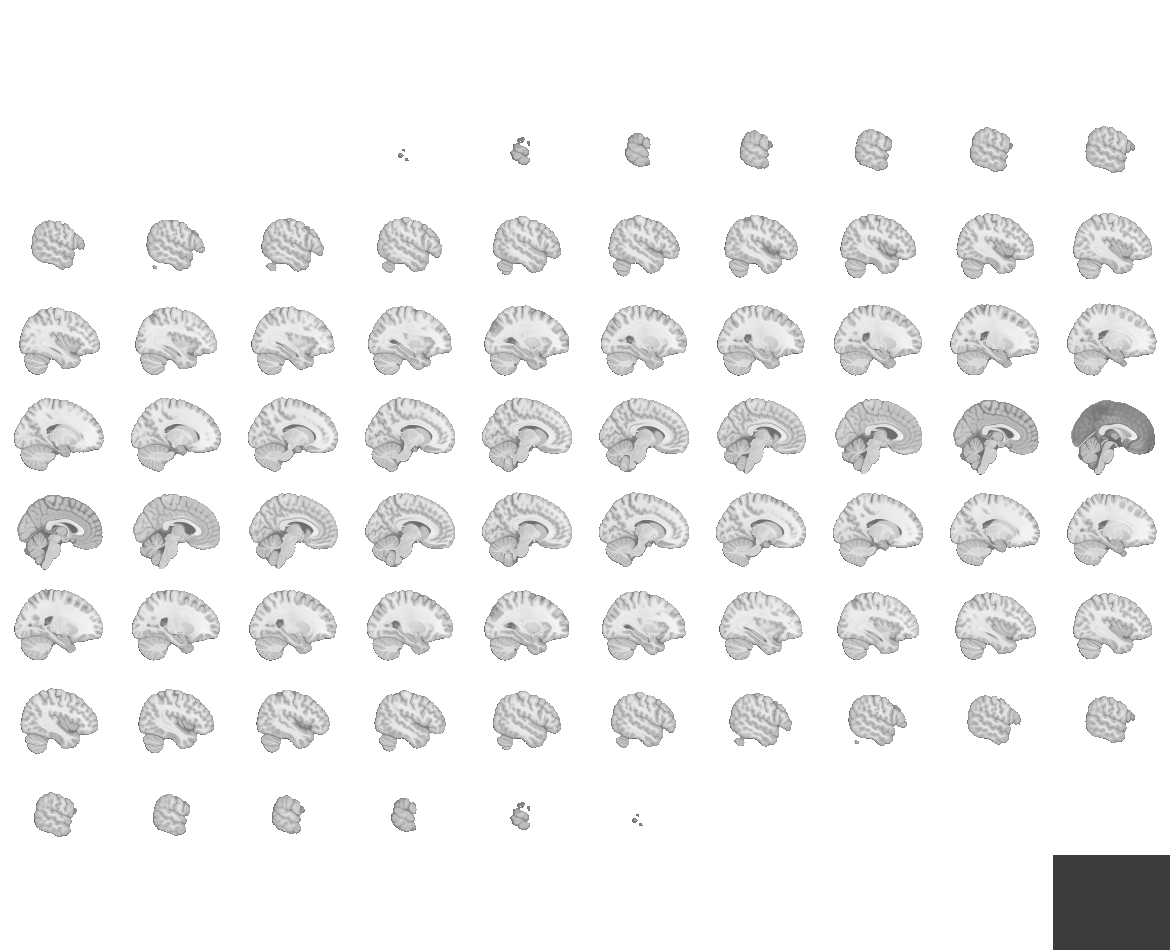
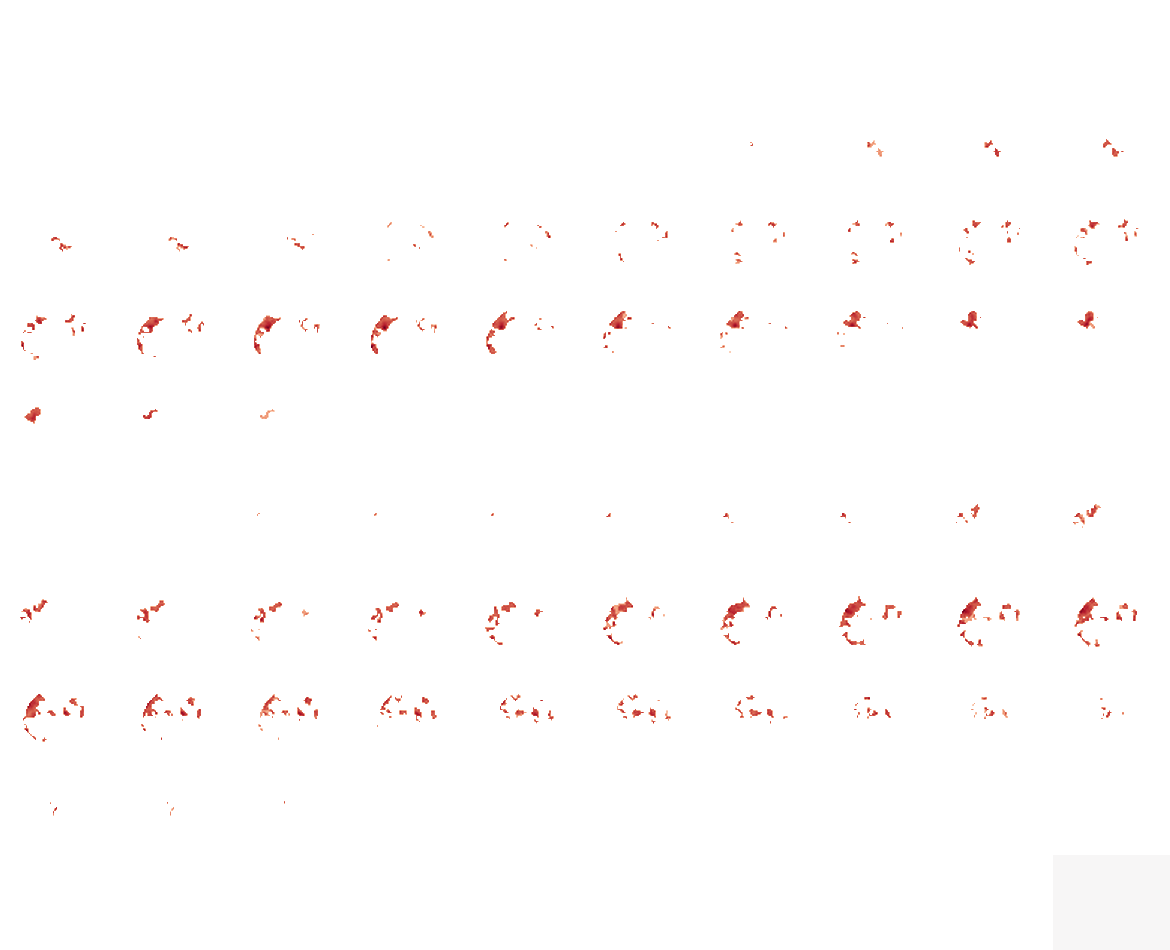

In [25]:
# Unique VA map
print('Unique VA (voxels where VA explains variance beyond CLIP):')
view = plotting.view_img(tmap_unique_va, draw_cross=False, black_bg=False, threshold=1)
view

Unique CLIP (voxels where CLIP explains variance beyond VA):


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_30808\200460396.py:3: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view = plotting.view_img(tmap_unique_clip, draw_cross=False, black_bg=False, threshold=5.5)



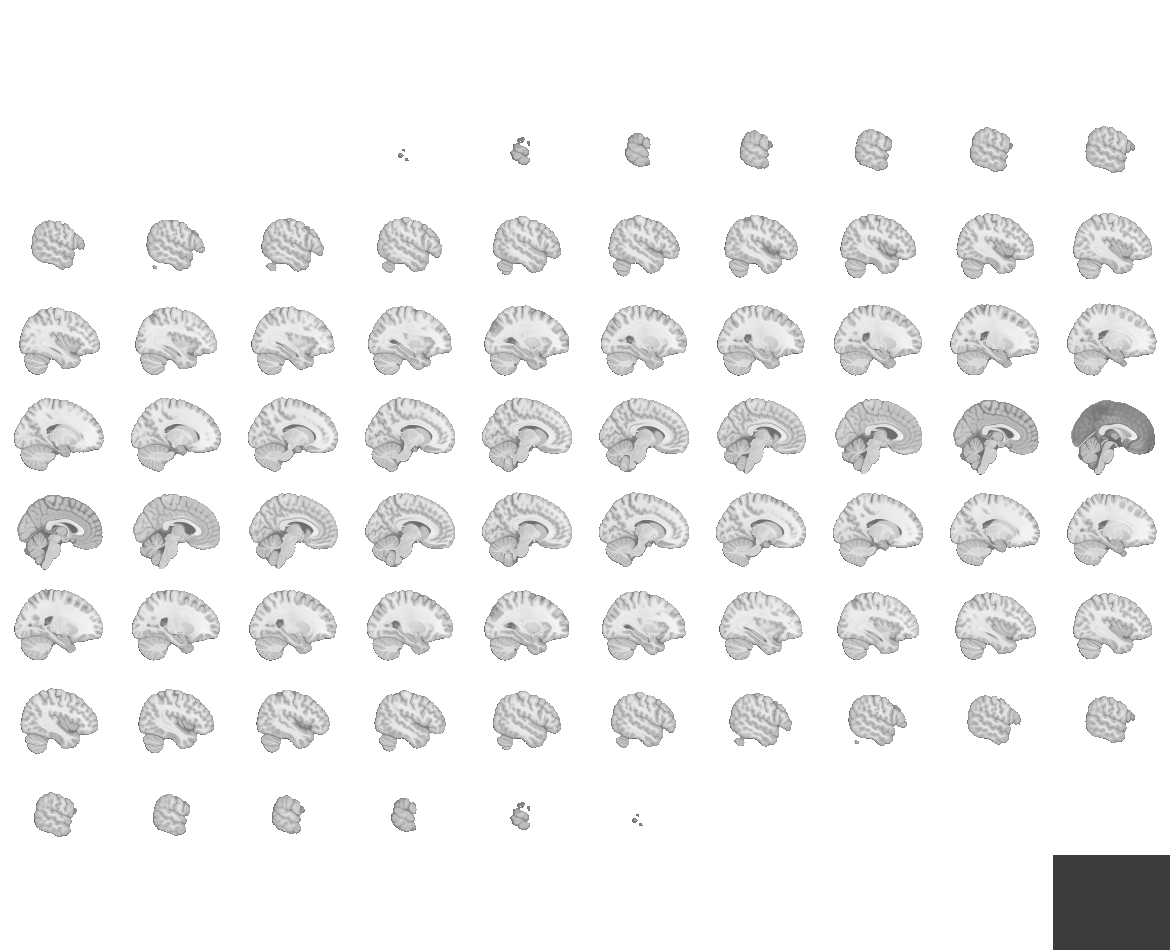
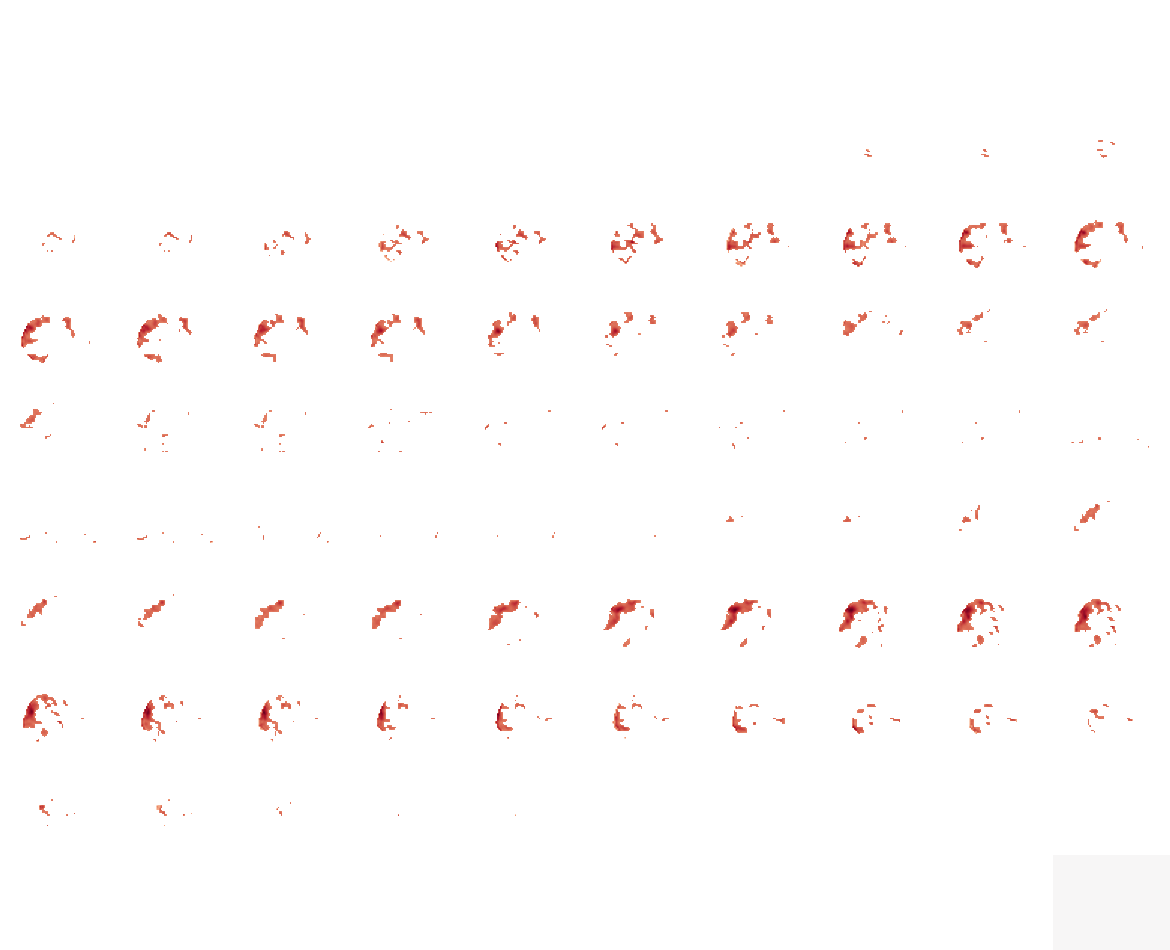

In [19]:
# Unique CLIP map
print('Unique CLIP (voxels where CLIP explains variance beyond VA):')
view = plotting.view_img(tmap_unique_clip, draw_cross=False, black_bg=False, threshold=5.5)
view

Shared VA-CLIP (voxels where VA and CLIP jointly explain variance):



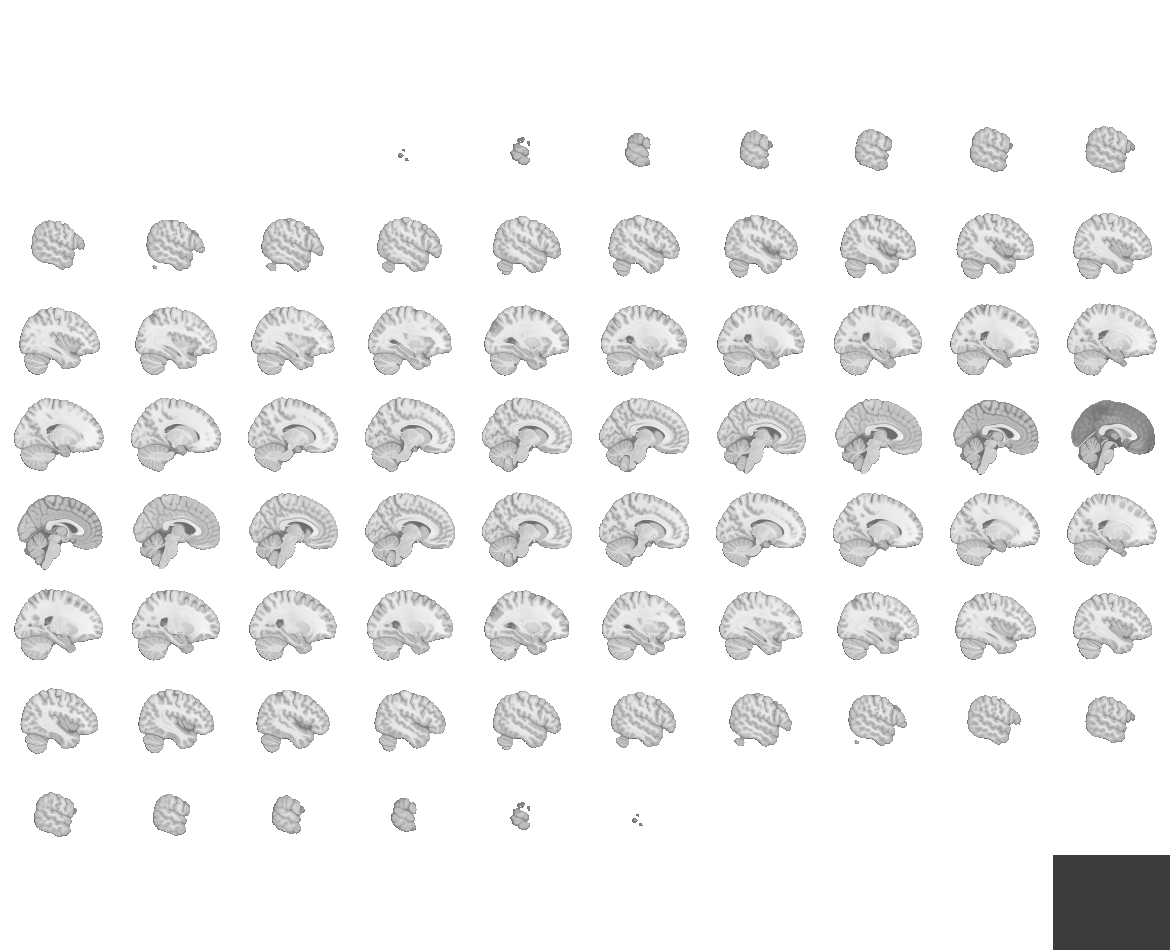
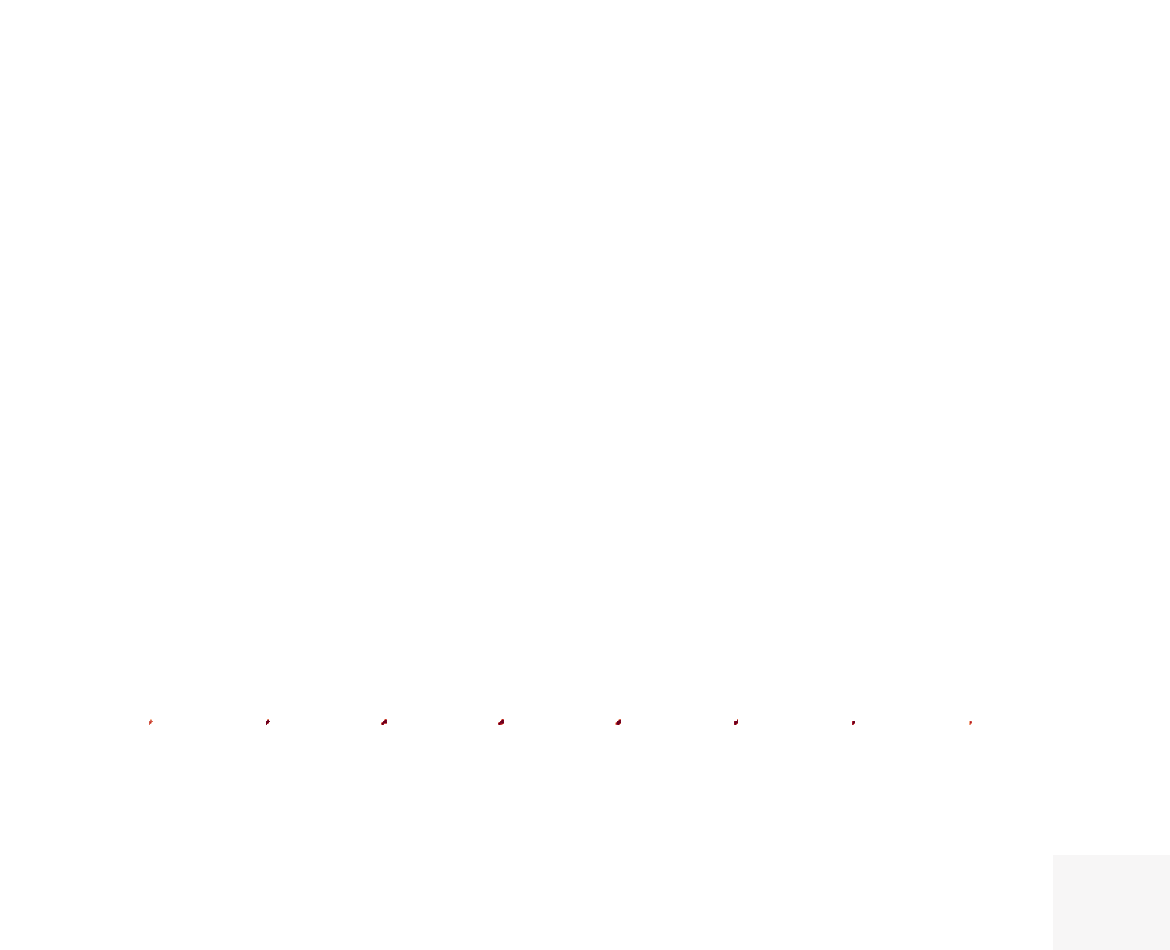

In [12]:
# Shared VA-CLIP map
print('Shared VA-CLIP (voxels where VA and CLIP jointly explain variance):')
view = plotting.view_img(tmap_shared, draw_cross=False, black_bg=False, threshold=0)
view

Difference: positive = VA > CLIP, negative = CLIP > VA



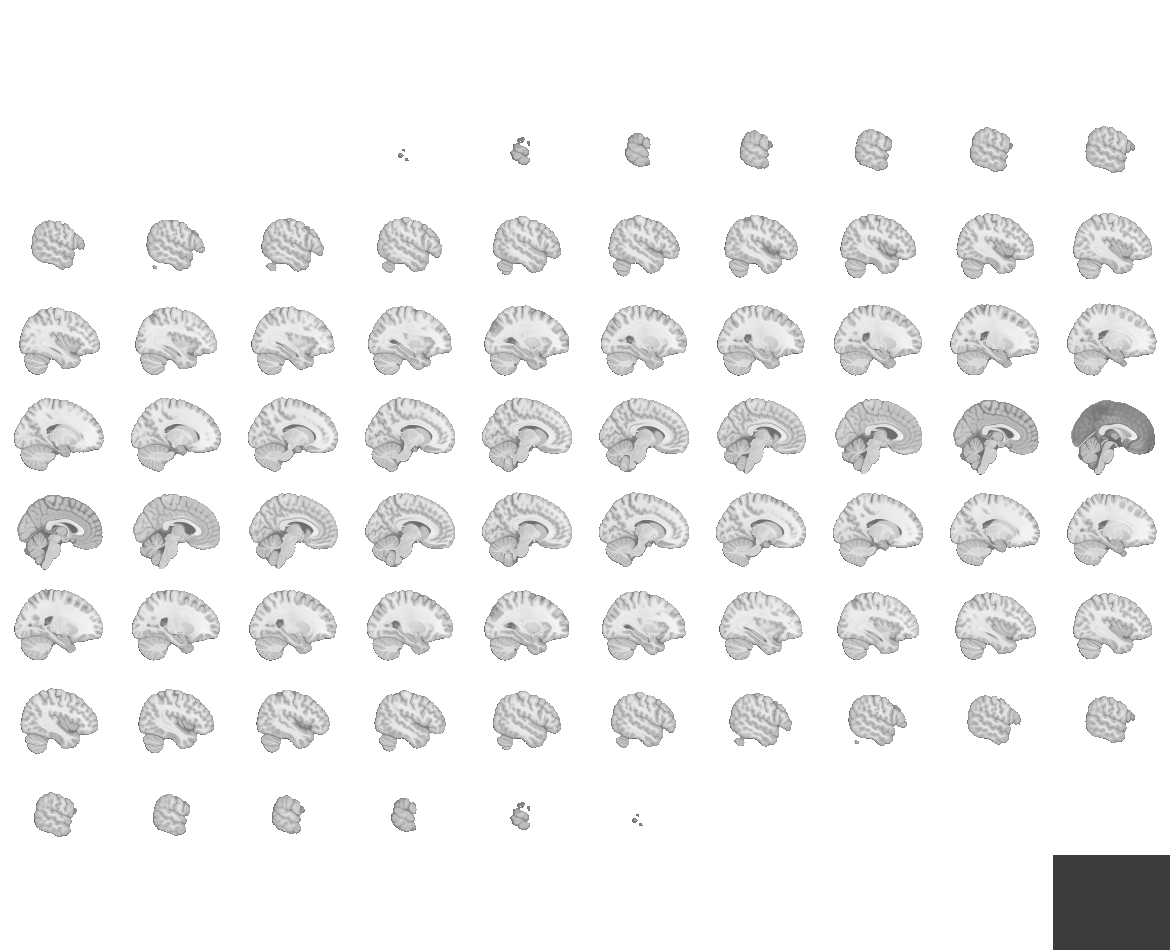
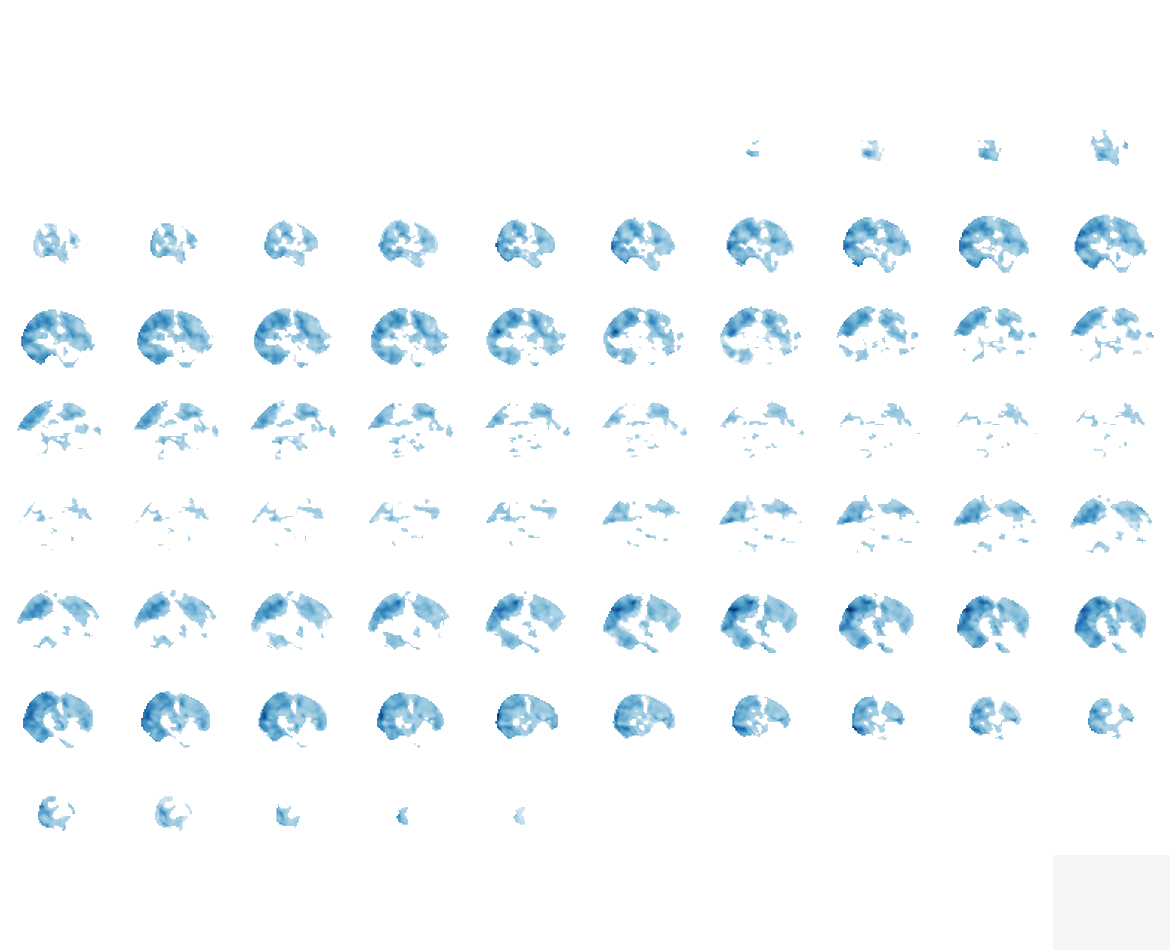

In [13]:
# Difference map: VA > CLIP (positive) vs CLIP > VA (negative)
print('Difference: positive = VA > CLIP, negative = CLIP > VA')
view = plotting.view_img(tmap_diff_cluster, draw_cross=False, black_bg=False,
                         symmetric_cmap=True, threshold=0)
view

## 7. Save outputs

In [ ]:
output_dir = r'.\outputs\tBrainmap\partial_variance'
os.makedirs(output_dir, exist_ok=True)

nib.save(tmap_unique_va, os.path.join(output_dir, 'tmap_unique_va_fdr05.nii.gz'))
nib.save(tmap_unique_clip, os.path.join(output_dir, 'tmap_unique_clip_fdr05.nii.gz'))
nib.save(tmap_shared, os.path.join(output_dir, 'tmap_shared_va_clip_fdr05.nii.gz'))
nib.save(tmap_diff_cluster, os.path.join(output_dir, 'tmap_diff_va_minus_clip_fdr05.nii.gz'))

print(f'Saved all maps to {output_dir}')